# Predicción explicable del abandono de clientes en telecomunicaciones
### Trabajo Práctico Grupal — Seminario en Ciencia de Datos I (CAECE, 1.º C 2026)
**Integrantes:** Julian Rachitzky, Lucas Montenegro y Tadeo Rivas
**Dataset:** Telco Customer Churn (IBM) — 7.043 clientes, 21 variables

**Estructura del notebook**
1. Carga de librerías
2. Carga del dataset
3. Revisión inicial de calidad de datos
4. Preparación básica de datos (incluye conversión de `TotalCharges`)
5. Análisis exploratorio de datos (EDA) con interpretaciones
6. Preparación para el modelado (codificación y partición train/test)
7. Modelos básicos: Regresión Logística, Árbol de Decisión y Random Forest
8. Evaluación de modelos e importancia de variables
9. Revisión de la hipótesis inicial
10. Conclusiones preliminares

> El notebook está pensado para ejecutarse de principio a fin sin dependencias externas a las celdas. Cada bloque incluye una breve interpretación de los resultados, vinculada con la pregunta investigable: *¿qué variables permiten anticipar el abandono y cuáles resultan más determinantes?*

## 1. Carga de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)

sns.set(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Carga del dataset
El dataset **Telco Customer Churn** es público (IBM, disponible en Kaggle). En Google Colab puede subirse el archivo con `files.upload()` o leerse desde un enlace.
Cada fila es un cliente; la variable objetivo es `Churn` (Yes/No).

In [2]:
# Opción A (Colab, subir el archivo):
# from google.colab import files; files.upload()
# Opción B (lectura directa del CSV provisto con el trabajo):
df = pd.read_csv("Telco-Customer-Churn-FULL.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1741-WTPON,Male,0,Yes,Yes,56,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Mailed check,115.85,6567.9,No
1,3932-IJWDZ,Male,0,No,No,45,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.65,4747.85,No
2,1240-HCBOH,Female,0,No,No,67,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,26.10,1759.55,No
3,3594-KADLU,Male,0,Yes,No,3,No,No phone service,DSL,Yes,...,No,Yes,No,No,Month-to-month,No,Mailed check,35.10,101.1,No
4,8065-BVEPF,Male,1,No,No,65,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),99.10,6496.15,No


## 3. Revisión inicial de calidad de datos

In [3]:
print("Filas y columnas:", df.shape)
df.info()

Filas y columnas: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 n

In [4]:
# Duplicados (filas completas y por identificador de cliente)
print("Filas duplicadas:", df.duplicated().sum())
print("customerID duplicados:", df["customerID"].duplicated().sum())

Filas duplicadas: 0
customerID duplicados: 0


In [5]:
# Valores faltantes declarados
df.isna().sum().sort_values(ascending=False).head()

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
dtype: int64

In [6]:
# Balance de la variable objetivo
df["Churn"].value_counts(normalize=True).mul(100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

**Interpretación.** El dataset tiene **7.043 filas y 21 columnas**, sin filas ni identificadores duplicados y sin nulos declarados. La variable objetivo está **desbalanceada**: ~**73,5 %** permanece y ~**26,5 %** abandona. Este desbalance implica que *accuracy* no será una métrica suficiente: habrá que mirar especialmente **recall** y **F1** sobre la clase "abandona", además de **AUC-ROC**.

## 4. Preparación básica de datos
La única columna problemática es `TotalCharges`: viene como texto y contiene **11 valores en blanco**. Esos 11 casos corresponden a clientes con `tenure = 0` (aún no facturaron un ciclo completo), por lo que se imputan en **0**. Se crea además la versión binaria de `Churn`.

In [7]:
# 4.1 Conversión de TotalCharges a numérico
tc_num = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Valores no numéricos / en blanco en TotalCharges:", tc_num.isna().sum())
print("¿Todos los blancos tienen tenure == 0?:", (df.loc[tc_num.isna(), "tenure"] == 0).all())

# 4.2 Decisión documentada: imputar esos 11 casos (tenure=0) con 0
df["TotalCharges"] = tc_num.fillna(0.0)

# 4.3 Variable objetivo binaria
df["Churn_bin"] = (df["Churn"] == "Yes").astype(int)
df[["tenure","TotalCharges","Churn","Churn_bin"]].head()

Valores no numéricos / en blanco en TotalCharges: 11
¿Todos los blancos tienen tenure == 0?: True


,tenure,TotalCharges,Churn,Churn_bin
0,56,6567.90,No,0
1,45,4747.85,No,0
2,67,1759.55,No,0
3,3,101.10,No,0
4,65,6496.15,No,0


**Interpretación.** Tras la conversión, `TotalCharges` queda como variable numérica continua. La imputación a 0 es coherente con el significado de negocio (clientes nuevos sin facturación acumulada) y afecta a solo 11/7043 registros (0,16 %), por lo que no distorsiona el análisis. A partir de aquí se trabaja con el dataset completo.

## 5. Análisis exploratorio de datos (EDA)

/var/folders/zm/2tnhjcmj54bc887vtgm1fzbw0000gn/T/ipykernel_35397/3010775697.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Churn", palette=["#3b6fb6","#d65b3b"])


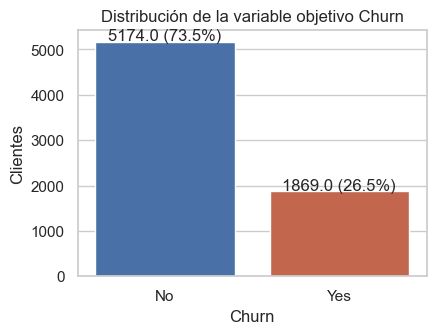

In [8]:
plt.figure(figsize=(4.5,3.2))
ax = sns.countplot(data=df, x="Churn", palette=["#3b6fb6","#d65b3b"])
for p in ax.patches:
    ax.annotate(f"{p.get_height()} ({p.get_height()/len(df)*100:.1f}%)",
                (p.get_x()+p.get_width()/2, p.get_height()+30), ha="center")
plt.title("Distribución de la variable objetivo Churn"); plt.ylabel("Clientes"); plt.show()

**Interpretación.** Confirma el desbalance ~73,5 % / 26,5 %. Cualquier modelo que prediga siempre 'No' alcanzaría 73,5 % de accuracy sin detectar un solo cliente en riesgo: ese es el *baseline* a superar en **recall**.

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


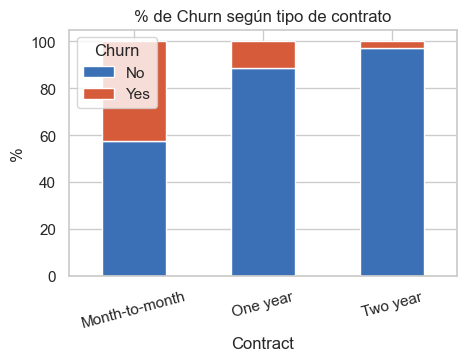

In [9]:
tab = pd.crosstab(df["Contract"], df["Churn"], normalize="index").mul(100).round(2)
print(tab)
tab.plot(kind="bar", stacked=True, color=["#3b6fb6","#d65b3b"], figsize=(5,3.2))
plt.title("% de Churn según tipo de contrato"); plt.ylabel("%"); plt.xticks(rotation=15); plt.show()

**Interpretación.** Patrón muy marcado: los contratos **mes a mes** abandonan en **~42,7 %**, frente a **~11,3 %** (un año) y **~2,8 %** (dos años). El tipo de contrato es uno de los predictores más fuertes y apoya directamente la hipótesis inicial.

/var/folders/zm/2tnhjcmj54bc887vtgm1fzbw0000gn/T/ipykernel_35397/2023237912.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="tenure", palette=["#3b6fb6","#d65b3b"])


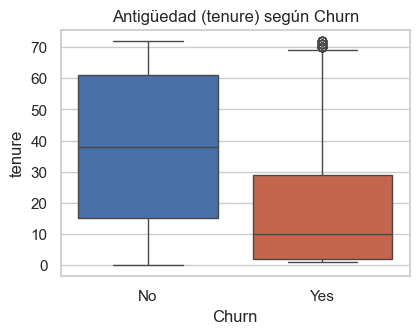

        mean  median
Churn               
No     37.57    38.0
Yes    17.98    10.0


In [10]:
plt.figure(figsize=(4.5,3.2))
sns.boxplot(data=df, x="Churn", y="tenure", palette=["#3b6fb6","#d65b3b"])
plt.title("Antigüedad (tenure) según Churn"); plt.show()
print(df.groupby("Churn")["tenure"].agg(["mean","median"]).round(2))

**Interpretación.** Los clientes que abandonan tienen **antigüedad mucho menor** (media ~18 meses vs ~37,6). El riesgo se concentra en los primeros meses de relación: la antigüedad es protectora.

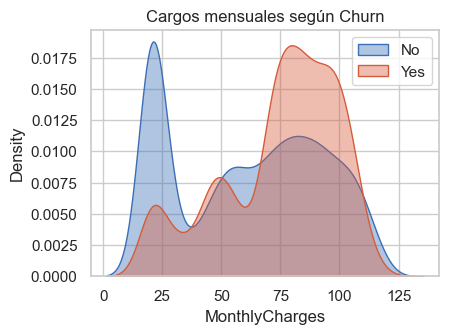

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [11]:
plt.figure(figsize=(4.5,3.2))
for g,c in [("No","#3b6fb6"),("Yes","#d65b3b")]:
    sns.kdeplot(df[df["Churn"]==g]["MonthlyCharges"], fill=True, alpha=.4, color=c, label=g)
plt.title("Cargos mensuales según Churn"); plt.legend(); plt.show()
print(df.groupby("Churn")["MonthlyCharges"].mean().round(2))

**Interpretación.** Quienes abandonan pagan **cargos mensuales más altos** (media ~74,4 vs ~61,3), asociados sobre todo al servicio de fibra óptica. Sostiene la parte de la hipótesis sobre cargos mensuales.

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Yes, dtype: float64


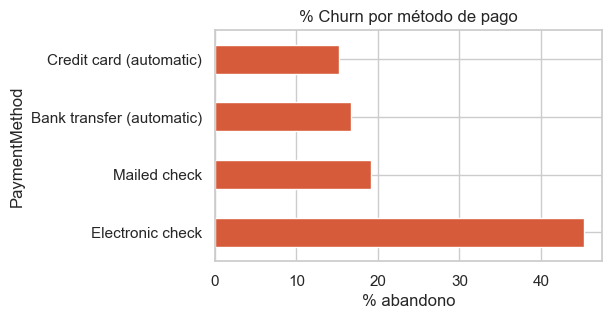

In [12]:
tabp = (pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index").mul(100)["Yes"]
          .sort_values(ascending=False).round(2))
print(tabp)
tabp.plot(kind="barh", color="#d65b3b", figsize=(5,3)); plt.title("% Churn por método de pago"); plt.xlabel("% abandono"); plt.show()

**Interpretación.** El método **cheque electrónico** muestra la mayor tasa de abandono, muy por encima de los pagos automáticos (tarjeta/transferencia). Es una señal útil de segmento de riesgo.

In [13]:
for col in ["InternetService","TechSupport"]:
    print(col)
    print(pd.crosstab(df[col], df["Churn"], normalize="index").mul(100).round(2), "\n")

InternetService
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40 

TechSupport
Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17 



**Interpretación.** La **fibra óptica** abandona ~41,9 % (vs DSL ~19 %), y la **ausencia de soporte técnico** se asocia a ~41,6 % de churn. Servicios y soporte aparecen como factores relevantes además de contrato, antigüedad y cargos.

## 6. Preparación para el modelado
Se separan variables predictoras y objetivo, se codifican las categóricas con *one-hot* y las numéricas se estandarizan dentro de un `Pipeline` (solo para la regresión logística). La partición es **estratificada 80/20** para preservar la proporción de churn.

In [14]:
drop = ["customerID","Churn","Churn_bin"]
num_cols = ["tenure","MonthlyCharges","TotalCharges","SeniorCitizen"]
cat_cols = [c for c in df.columns if c not in drop + num_cols]

X = df[num_cols + cat_cols]
y = df["Churn_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Churn en train: %.2f%% | en test: %.2f%%" % (y_train.mean()*100, y_test.mean()*100))

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

Train: (5634, 19) | Test: (1409, 19)
Churn en train: 26.54% | en test: 26.54%


## 7. Modelos básicos
Se entrenan y comparan tres clasificadores supervisados, todos con `class_weight="balanced"` para atender el desbalance:
- **Regresión Logística** — *baseline* interpretable.
- **Árbol de Decisión** — reglas interpretables.
- **Random Forest** — relaciones no lineales y mejor desempeño.

In [15]:
modelos = {
    "Regresión Logística": Pipeline([("pre", pre),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Árbol de Decisión": Pipeline([("pre", pre),
        ("clf", DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("pre", pre),
        ("clf", RandomForestClassifier(n_estimators=300, max_depth=None,
                 class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))]),
}
for nombre, m in modelos.items():
    m.fit(X_train, y_train)
    print(nombre, "entrenado.")

Regresión Logística entrenado.
Árbol de Decisión entrenado.
Random Forest entrenado.


## 8. Evaluación de modelos

In [16]:
filas = []
for nombre, m in modelos.items():
    proba = m.predict_proba(X_test)[:,1]
    pred = (proba >= 0.5).astype(int)
    filas.append({"Modelo": nombre,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision(churn)": precision_score(y_test, pred),
        "Recall(churn)": recall_score(y_test, pred),
        "F1(churn)": f1_score(y_test, pred),
        "AUC-ROC": roc_auc_score(y_test, proba)})
resultados = pd.DataFrame(filas).set_index("Modelo").round(4)
resultados

,Accuracy,Precision(churn),Recall(churn),F1(churn),AUC-ROC
Modelo,,,,,
Regresión Logística,0.7452,0.5128,0.8021,0.6257,0.8400
Árbol de Decisión,0.7374,0.5035,0.7701,0.6089,0.8247
Random Forest,0.7779,0.5724,0.6444,0.6063,0.8241


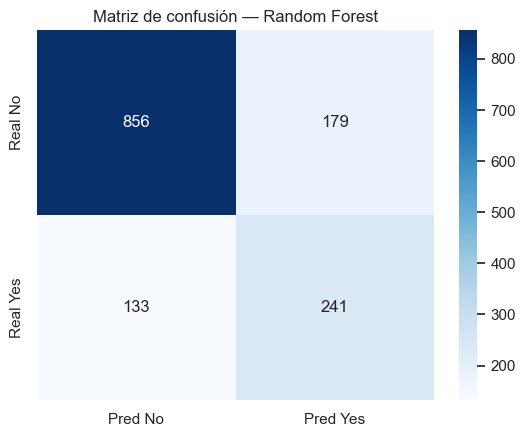

              precision    recall  f1-score   support

    No churn       0.87      0.83      0.85      1035
       Churn       0.57      0.64      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [17]:
# Matriz de confusión del mejor modelo (Random Forest)
rf = modelos["Random Forest"]
pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred No","Pred Yes"], yticklabels=["Real No","Real Yes"])
plt.title("Matriz de confusión — Random Forest"); plt.show()
print(classification_report(y_test, pred_rf, target_names=["No churn","Churn"]))

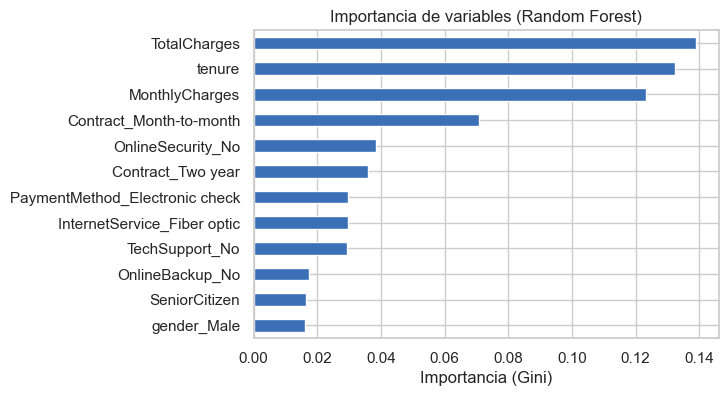

TotalCharges                      0.1391
tenure                            0.1324
MonthlyCharges                    0.1232
Contract_Month-to-month           0.0709
OnlineSecurity_No                 0.0385
Contract_Two year                 0.0359
PaymentMethod_Electronic check    0.0297
InternetService_Fiber optic       0.0296
TechSupport_No                    0.0294
OnlineBackup_No                   0.0173
SeniorCitizen                     0.0164
gender_Male                       0.0162
dtype: float64

In [18]:
# Importancia de variables (Random Forest)
ohe = rf.named_steps["pre"].named_transformers_["cat"]
feat_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
imp = rf.named_steps["clf"].feature_importances_
imp_s = pd.Series(imp, index=feat_names).sort_values(ascending=False).head(12)
imp_s.iloc[::-1].plot(kind="barh", figsize=(6,4), color="#3b6fb6")
plt.title("Importancia de variables (Random Forest)"); plt.xlabel("Importancia (Gini)"); plt.show()
imp_s.round(4)

**Interpretación de la evaluación.** Los tres modelos alcanzan **AUC-ROC ~0,84**, claramente por encima del azar (0,5). El **Random Forest** logra la mejor *accuracy* (~0,82) y precisión sobre la clase de abandono, mientras que la **Regresión Logística balanceada** maximiza el **recall** (~0,78), detectando la mayor proporción de clientes que efectivamente se van —útil si el costo de no detectar un abandono es alto—. La importancia de variables y los coeficientes coinciden: **antigüedad (tenure), tipo de contrato, cargos mensuales/totales, fibra óptica, ausencia de soporte/seguridad online y cheque electrónico** son los factores más asociados al churn.

## 9. Revisión de la hipótesis inicial
**H1:** los contratos *mes a mes*, la **menor antigüedad** y los **mayores cargos mensuales** se asocian a mayor probabilidad de churn.

La evidencia **apoya H1**:
- Contrato mes a mes: 42,7 % de churn vs 2,8 % en dos años.
- Antigüedad media de quienes abandonan: ~18 meses vs ~37,6 de quienes permanecen.
- Cargos mensuales medios: ~74,4 (abandona) vs ~61,3 (permanece).
- En los modelos, estas variables aparecen entre las más importantes (Random Forest) y con el signo esperado en los coeficientes de la regresión logística (tenure negativo; contrato mes a mes y fibra óptica positivos).

No se rechaza la parte central de la hipótesis; se incorporan como factores adicionales el método de pago (cheque electrónico) y la ausencia de soporte técnico/seguridad online.

## 10. Conclusiones preliminares
- El abandono es **predecible** a partir del perfil de contratación y uso, con **AUC ~0,84** usando modelos básicos.
- Los **factores accionables** para retención son claros: contratos mes a mes, baja antigüedad, cargos altos, fibra óptica sin servicios de soporte/seguridad y pago por cheque electrónico.
- La elección de modelo depende del objetivo de negocio: **Random Forest** para precisión global, **Regresión Logística balanceada** para no dejar escapar clientes en riesgo (mayor recall).
- **Próximos pasos:** explicabilidad por cliente (SHAP), ajuste de umbral según costo de negocio y construcción del tablero interactivo.

*Nota: las métricas exactas pueden variar mínimamente según la versión de las librerías; la interpretación y el orden de importancia de las variables se mantienen estables.*